In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import os
import sys
sys.path.append(os.path.abspath(".."))
from src.Linear_Model.linear_Regression import LinearRegression
from sklearn.metrics import accuracy_score


In [2]:
df=pd.read_csv("../data/housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


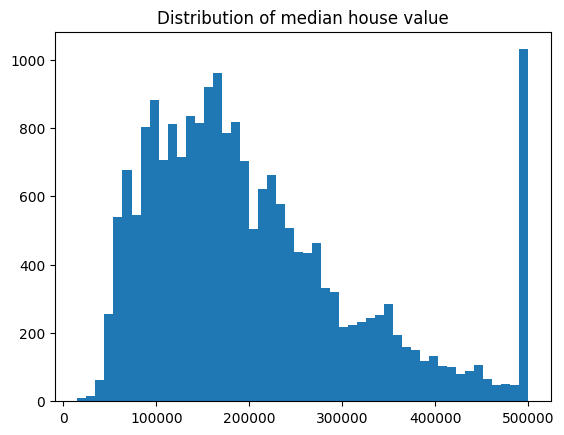

In [3]:
plt.hist(x='median_house_value',bins=50,data=df)
plt.title("Distribution of median house value")
plt.show()
#as we can see the data is negative skewed

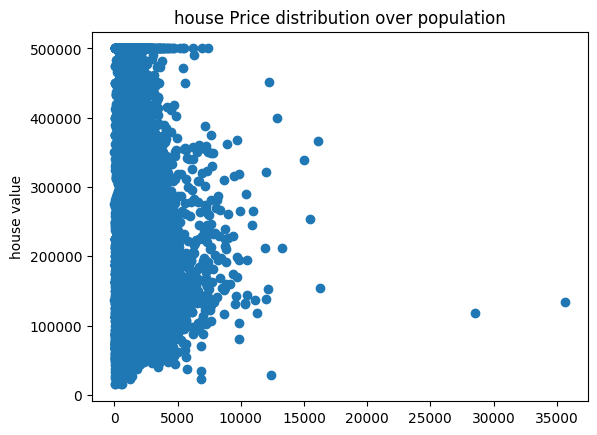

In [4]:
plt.scatter(x='population',y='median_house_value',data=df)
plt.xlabel=("Population")
plt.ylabel("house value")
plt.title("house Price distribution over population")
plt.show()


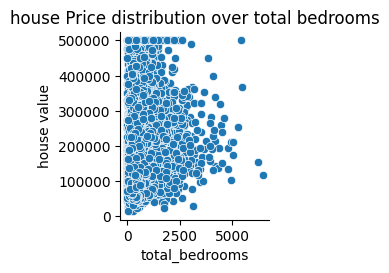

In [5]:
sns.pairplot(x_vars='total_bedrooms',y_vars='median_house_value',data=df)
plt.xlabel=("households")
plt.ylabel("house value")
plt.title("house Price distribution over total bedrooms")
plt.show()


In [6]:
# to convert the ocean proximity from Catagorical value to numerical since LR expects numerical value
from sklearn.preprocessing import OneHotEncoder 
encoder=OneHotEncoder(handle_unknown='ignore',sparse_output=False)
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ocean_encoded = encoder.fit_transform(df[['ocean_proximity']])
ocean_df = pd.DataFrame(
    ocean_encoded, 
    columns=encoder.get_feature_names_out(['ocean_proximity'])
)
df = pd.concat([df.drop('ocean_proximity', axis=1), ocean_df], axis=1)

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0


In [20]:
# as we saw most of the data is negatively skewed so let's try log transforming the Target.
df['total_bedrooms']=df['total_bedrooms'].fillna(df['total_bedrooms'].mean())#assigning mean for the Null values

Y=np.log1p(df['median_house_value'])

X=df.drop(columns='median_house_value')

Y=np.reshape(Y,(-1,1))

x_trian,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,random_state=42)

model=LinearRegression(10000,0.1)

model.fit(x_trian,y_train)





In [21]:
from sklearn.metrics import mean_squared_error,r2_score
y_hat=model.predict(x_test)
mse = mean_squared_error(y_test, y_hat)
rmse = np.sqrt(mse)
accuracy = accuracy_score(y_test.round(), y_hat.round())
r2=r2_score(y_test,y_hat)

print("RMSE:", rmse)
print("Accuracy:", accuracy*100)
print("R2 Score:", r2*100)


RMSE: 0.3381650888570774
Accuracy: 73.53036175710595
R2 Score: 64.69900415357026
